# Spam Email Detection using NLP and Logistic Regression

This project builds a machine learning model that detects **spam emails** using natural language processing techniques.

Email messages are first converted into numerical features using the **Bag-of-Words** representation, which transforms text into vectors of word counts. These features are then used to train a **Logistic Regression classifier** that predicts whether an email is spam or legitimate (ham).

The project demonstrates a full machine learning pipeline including:

- Data preprocessing
- Text feature extraction
- Train/test splitting
- Model training
- Model evaluation
- Interpretation of learned features

The final model achieves high accuracy while remaining interpretable, allowing us to examine which words most strongly influence spam classification.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer

## Loading and Exploring the Dataset

The dataset contains email messages along with labels indicating whether each email is **spam** or **legitimate (ham)**.

Each email includes:

- a **subject line**
- the **body text**
- a **label** indicating spam (1) or ham (0)

Before training a model, it is important to inspect the dataset to understand its structure, identify missing values, and verify that the labels are correctly formatted.

In [5]:
df = pd.read_csv("CEAS_08.csv")
df.head()
df.info()
df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


,count
label,
1,21842
0,17312


In [6]:
print(df)

                                                  sender  \
0                       Young Esposito <Young@iworld.de>   
1                           Mok <ipline's1983@icable.ph>   
2      Daily Top 10 <Karmandeep-opengevl@universalnet...   
3                     Michael Parker <ivqrnai@pobox.com>   
4      Gretchen Suggs <externalsep1@loanofficertool.com>   
...                                                  ...   
39149    CNN Alerts <charlene-detecton@btcmarketing.com>   
39150           CNN Alerts <idgetily1971@careplusnj.org>   
39151                   Abhijit Vyas <xpojhbz@gmail.com>   
39152              Joseph Brennan <vupzesm@columbia.edu>   
39153                Christian Heimes <wluhe@cheimes.de>   

                                             receiver  \
0                         user4@gvc.ceas-challenge.cc   
1                       user2.2@gvc.ceas-challenge.cc   
2                       user2.9@gvc.ceas-challenge.cc   
3      SpamAssassin Dev <xrh@spamassassin.apache.or

## Handling Missing Values

Some emails in the dataset contain missing values in the **subject** field.

Since machine learning models cannot process missing text values, we replace any missing entries with empty strings. This ensures that every email contains valid text before we combine the subject and body into a single message.

## Creating a Unified Text Feature

To simplify the model input, the **subject** and **body** fields are combined into a single column called `Text`.

This represents the full content of each email message. By combining these fields, the model can learn patterns from both the subject line and the email body simultaneously.

In [13]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df['Text'] = df['subject'] + "" + df['body']

X = df['Text']
y = df['label']

## Splitting the Dataset

To evaluate the model fairly, the dataset is divided into two parts:

- **Training set (80%)** – used to train the model
- **Test set (20%)** – used to evaluate performance on unseen data

This separation ensures the model is tested on emails it has never seen before, providing a realistic estimate of how it would perform in practice.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
X_train.isna().sum()

np.int64(0)

## Converting Text into Numerical Features

Machine learning models cannot directly process raw text. To address this, we use **CountVectorizer**, which implements the **Bag-of-Words** approach.

This method works by:

1. Building a vocabulary of all unique words in the training data
2. Representing each email as a vector indicating how many times each word appears

For example, if the vocabulary contains the words:

`["free", "offer", "meeting"]`

Then an email containing:

`"free offer free"`

would be represented as:

`[2, 1, 0]`

This transformation converts text data into a numerical format suitable for machine learning models.

In [19]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## Training the Logistic Regression Model

A **Logistic Regression classifier** is used to learn patterns that distinguish spam emails from legitimate messages.

Logistic Regression works by assigning weights to each feature (in this case, words). Words that frequently appear in spam emails receive **positive weights**, while words more common in legitimate emails receive **negative weights**.

During training, the model learns the optimal weights that minimize classification errors on the training dataset.

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

## Evaluating Model Performance

After training, the model is evaluated using the **test dataset**, which contains emails the model has not seen before.

We measure performance using several metrics:

- **Accuracy** – overall percentage of correct predictions
- **Precision** – how many predicted spam emails are actually spam
- **Recall** – how many spam emails were correctly detected
- **F1 Score** – a balanced measure combining precision and recall

These metrics provide a more complete view of model performance than accuracy alone.

In [22]:
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9952751883539778
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3490
           1       0.99      1.00      1.00      4341

    accuracy                           1.00      7831
   macro avg       1.00      0.99      1.00      7831
weighted avg       1.00      1.00      1.00      7831



## Interpreting Important Words

One advantage of Logistic Regression is that it provides **interpretable coefficients** for each feature.

By examining the model’s learned weights, we can identify which words are most strongly associated with spam emails. Words with larger positive coefficients increase the probability that an email is classified as spam.

Visualizing these words helps us understand the patterns the model has learned from the dataset.

In [23]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

top_spam = sorted(zip(coefficients, feature_names))[-20:]
top_ham = sorted(zip(coefficients, feature_names))[:20]

print("Top spam words:")
for coef, word in top_spam:
    print(word)

print("\nTop ham words:")
for coef, word in top_ham:
    print(word)

Top spam words:
made
payment
your
our
write
bank
replica
sex
person
inches
watches
cy
health
lwv
http
custom
her
men
livefilestore
love

Top ham words:
thanks
ie
opensuse
fork
wrote
rant
ta
uai
patch
thank
ilug
cheers
re
python
tony
triptracker
slideshow
org
postfix
spamassassin


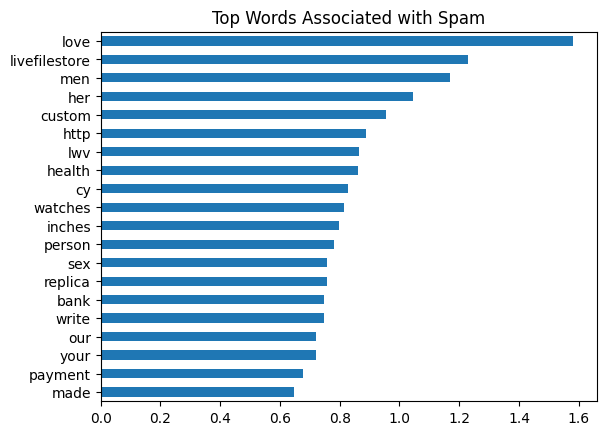

In [24]:
feature_names = vectorizer.get_feature_names_out()
coeffs = pd.Series(model.coef_[0], index=feature_names)

coeffs.sort_values().tail(20).plot(kind="barh")
plt.title("Top Words Associated with Spam")
plt.show()

## Conclusion

In this project, I built a machine learning model capable of detecting spam emails using natural language processing techniques. By converting email text into numerical features using the **Bag-of-Words** method, I trained a **Logistic Regression classifier** that distinguishes between spam and legitimate emails.

The model achieved very high performance on the test dataset, demonstrating that spam emails often contain distinctive vocabulary patterns that can be effectively captured using simple text representations.

In addition to training the classifier, I examined the model’s learned coefficients to identify which words most strongly influence spam classification. Words related to promotions, financial transactions, and links were strong indicators of spam, while technical discussion terms were more commonly associated with legitimate emails.

This project demonstrates how classical NLP techniques combined with interpretable machine learning models can provide an effective solution for text classification problems.

In future work, I plan to extend this approach by experimenting with **TF-IDF feature extraction**, incorporating **URL-based features**, and applying similar techniques to detect **phishing emails**, which will form the foundation of a more advanced email security system.